In [30]:
!pip install -q xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

sns.set(style="whitegrid")


In [18]:
df = pd.read_csv("Country-data.csv")

print(df.shape)
df.head()

(167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [19]:
df.columns = [c.strip().lower() for c in df.columns]


df.isnull().sum()


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [31]:
numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("\nNumeric Columns:")
print(numeric_cols)



Numeric Columns:
['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


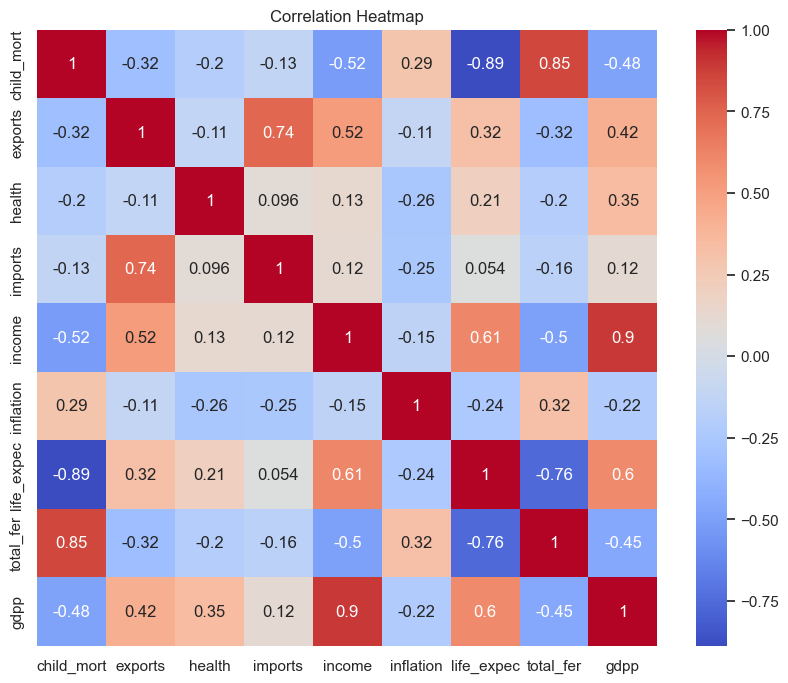

In [32]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [33]:
if "country" in df.columns:
    features = df.drop(columns=["country"])
else:
    features = df.copy()

# Keep only numeric columns
features = features.select_dtypes(
    include=["int64","float64"]
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

print("Scaled Shape:", X_scaled.shape)

Scaled Shape: (167, 9)


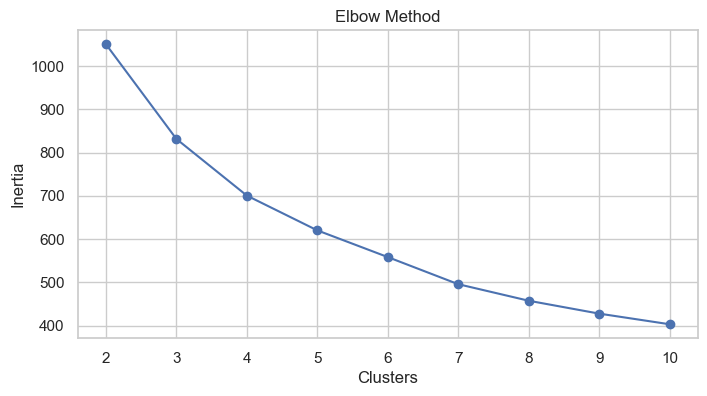

In [34]:

inertias = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertias.append(model.inertia_)

plt.figure(figsize=(8,4))

plt.plot(
    range(2,11),
    inertias,
    marker="o"
)

plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


In [35]:

best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["kmeans_cluster"] = kmeans.fit_predict(
    X_scaled
)

sil_score = silhouette_score(
    X_scaled,
    df["kmeans_cluster"]
)

print("\nSilhouette Score:", sil_score)



Silhouette Score: 0.28329575683463126


In [36]:

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df["dbscan_cluster"] = dbscan.fit_predict(
    X_scaled
)

print("\nDBSCAN Cluster Counts:")
print(df["dbscan_cluster"].value_counts())



DBSCAN Cluster Counts:
dbscan_cluster
 0    137
-1     30
Name: count, dtype: int64


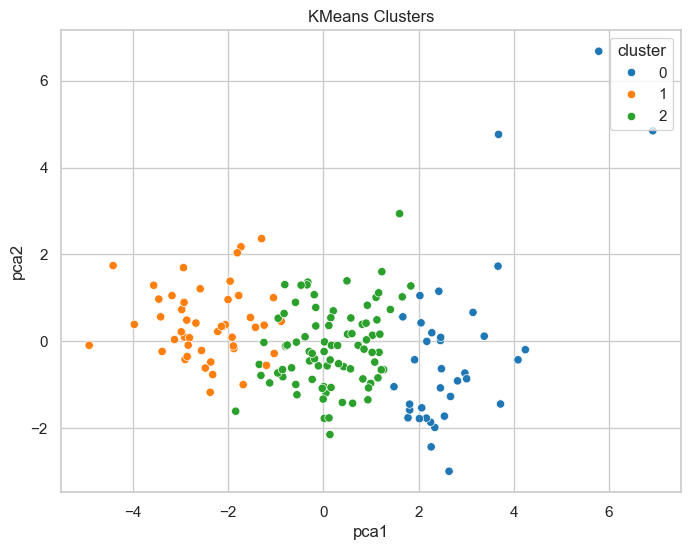

In [37]:

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({
    "pca1": X_pca[:,0],
    "pca2": X_pca[:,1],
    "cluster": df["kmeans_cluster"]
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=viz,
    x="pca1",
    y="pca2",
    hue="cluster",
    palette="tab10"
)

plt.title("KMeans Clusters")
plt.show()

In [38]:

X = df[numeric_cols]
y = df["kmeans_cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [39]:

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

print("\nRandom Forest Accuracy:")
print(
    accuracy_score(
        y_test,
        rf_pred
    )
)

print("\nRandom Forest Report:")
print(
    classification_report(
        y_test,
        rf_pred
    )
)



Random Forest Accuracy:
1.0

Random Forest Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [40]:

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    objective="multi:softmax",
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

print("\nXGBoost Accuracy:")
print(
    accuracy_score(
        y_test,
        xgb_pred
    )
)

print("\nXGBoost Report:")
print(
    classification_report(
        y_test,
        xgb_pred
    )
)



XGBoost Accuracy:
0.9705882352941176

XGBoost Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



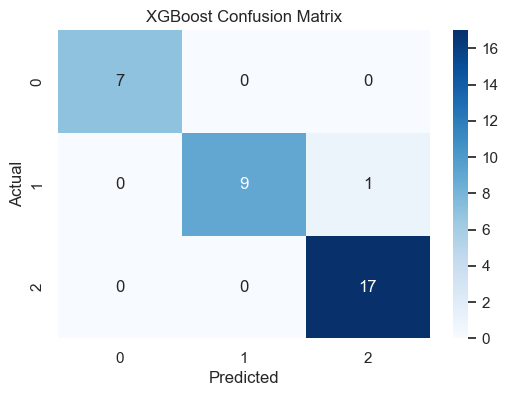

In [41]:

cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



Feature Importance:
      Feature  Importance
0  child_mort    0.251179
8        gdpp    0.199593
7   total_fer    0.174030
6  life_expec    0.161208
4      income    0.144110
2      health    0.031770
5   inflation    0.016104
3     imports    0.011648
1     exports    0.010357


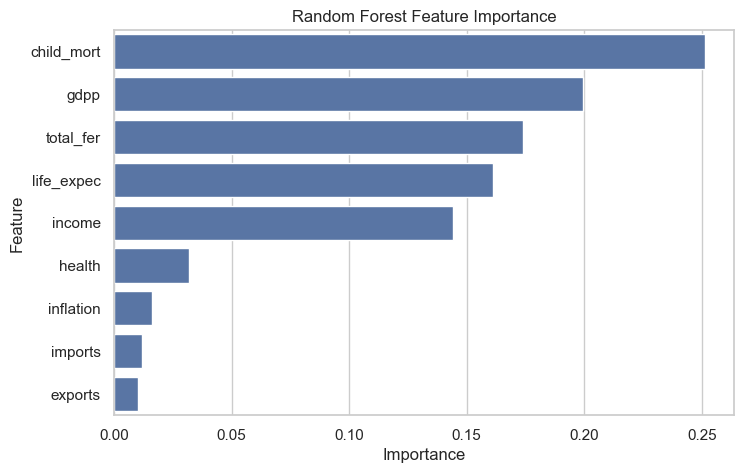

In [42]:

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.show()


In [43]:

profile = (
    df.groupby("kmeans_cluster")[numeric_cols]
      .mean()
      .round(2)
)

print("\nCluster Profiles:")
print(profile)


Cluster Profiles:
                child_mort  exports  health  imports    income  inflation  \
kmeans_cluster                                                              
0                     5.00    58.74    8.81    51.49  45672.22       2.67   
1                    92.96    29.15    6.39    42.32   3942.40      12.02   
2                    21.93    40.24    6.20    47.47  12305.60       7.60   

                life_expec  total_fer      gdpp  
kmeans_cluster                                   
0                    80.13       1.75  42494.44  
1                    59.19       5.01   1922.38  
2                    72.81       2.31   6486.45  


      Feature  Importance
0  child_mort    0.251179
8        gdpp    0.199593
7   total_fer    0.174030
6  life_expec    0.161208
4      income    0.144110
2      health    0.031770
5   inflation    0.016104
3     imports    0.011648
1     exports    0.010357


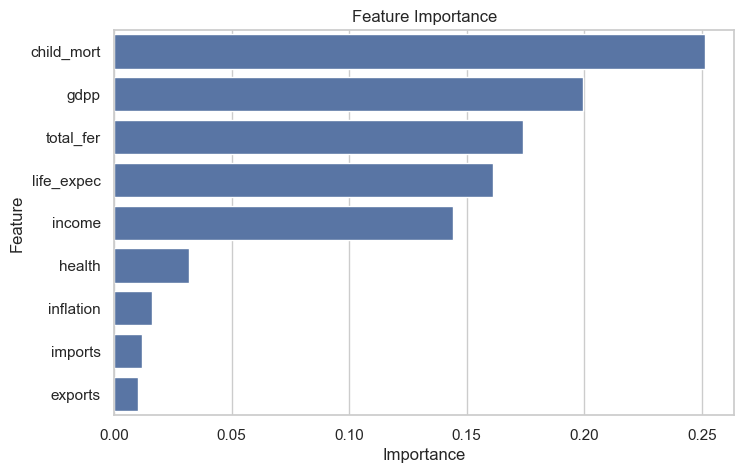

In [46]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [45]:
profile = df.groupby(
    "kmeans_cluster"
)[numeric_cols].mean().round(2)

profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45
